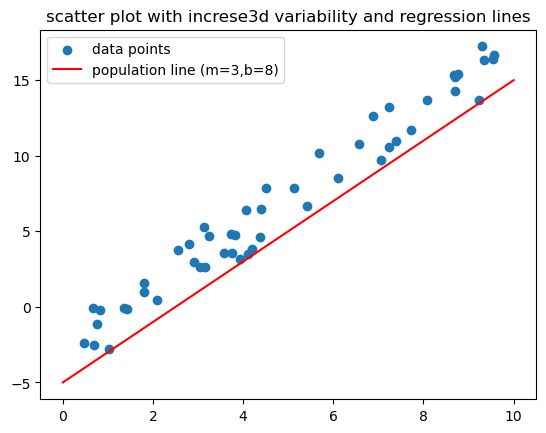

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x=10*np.random.rand(50)
y=2*x-5 + np.random.rand(50) *4

x=x.reshape(-1,1)
model = LinearRegression()
model.fit(x,y)

y_pred =model.predict(x)

plt.scatter(x,y,label="data points")
plt.xlabel=("X")
plt.ylabel=("y")
plt.title("scatter plot with increse3d variability and regression lines")

# plot actual population line
x_line=np.linspace(0,10,100)
y_actual = 2*x_line-5
plt.plot(x_line,y_actual,'r',label="population line (m=3,b=8)")

# plot estimated regression line
y_estimated = model.coef_[0]*x_line+model.intercept_
plt.plot(x_line, y_estimated ,'g',label=f"estimated line (m={model.coef_[0]:2f},b={model.intercept_:2f})")

# add legend and show pfloat
plt.legend()
plt.show()


In [7]:
import pandas as pd
import statsmodels.api as sm

# Load the dataset
url = pd.read_csv("C:/Users/DELL/CAMPUS X/Advertising.csv")
data = pd.read_csv(url, index_col=0)

# Define the independent variables (add a constant for the intercept)
X = data[['TV', 'Radio', 'Newspaper' ]]
X = sm.add_constant(X)

# Define the dependent variable
y = data['Sales' ]

# Fit the model using the independent and dependent variables
model = sm.OLS(y, X).fit()

# Print the summary of the model
print(model.summary())

TypeError: argument of type 'method' is not iterable

In [11]:
import pandas as pd
import statsmodels.api as sm

# Load the dataset
data = pd.read_csv("C:/Users/DELL/CAMPUS X/Advertising.csv", index_col=0)

# Independent variables
X = data[['TV', 'Radio', 'Newspaper']]

# Add intercept
X = sm.add_constant(X)

# Dependent variable
y = data['Sales']

# Fit model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sat, 18 Jul 2026   Prob (F-statistic):           1.58e-96
Time:                        10:50:17   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [9]:
url = pd.read_csv("C:/Users/DELL/CAMPUS X/Advertising.csv")
url.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Generate synthetic data
np.random.seed(42)
n = 100
x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)
irrelevant_predictors = np.random.normal(0, 1, (n, 10))

y =2*x1+3*x2+ np.random.normal(0, 1, n)

# Helper function to calculate adjusted R-squared
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

# Fit linear regression models with different predictors
X = pd.DataFrame({'x1':x1, 'x2':x2})

X_with_irrelevant = pd.concat([X] + [pd.Series(irrelevant_predictors[:, i], name=f"irrelevant_{i}") for i in range(10)], axis=1)

model1 = LinearRegression().fit(X, y)
model2 = LinearRegression().fit(X_with_irrelevant, y)

# Calculate R-squared and adjusted R-squared for each model
models = [('Model with relevant predictors', model1, X.shape[1]), ( 'Model with irrelevant predictors', model2, X_with_irrelevant. shape[1])]

for name, model, k in models:
    r2= r2_score(y, model.predict(X_with_irrelevant.iloc[:, :k]))
    adj_r2 = adjusted_r2(r2, n, k)
    print(f"{name}: R-squared = {r2 :.3f}, Adjusted R-squared = {adj_r2 :.3f}")

Model with relevant predictors: R-squared = 0.912, Adjusted R-squared = 0.910
Model with irrelevant predictors: R-squared = 0.919, Adjusted R-squared = 0.908


In [23]:
X

,x1,x2
0,0.496714,-1.415371
1,-0.138264,-0.420645
2,0.647689,-0.342715
3,1.523030,-0.802277
4,-0.234153,-0.161286
...,...,...
95,-1.463515,0.385317
96,0.296120,-0.883857
97,0.261055,0.153725
98,0.005113,0.058209


In [25]:
X_with_irrelevant.head()

,x1,x2,irrelevant_0,irrelevant_1,irrelevant_2,irrelevant_3,irrelevant_4,irrelevant_5,irrelevant_6,irrelevant_7,irrelevant_8,irrelevant_9
0,0.496714,-1.415371,0.357787,0.560785,1.083051,1.053802,-1.377669,-0.937825,0.515035,0.513786,0.515048,3.852731
1,-0.138264,-0.420645,0.570891,1.135566,0.954002,0.651391,-0.315269,0.758969,-0.772825,-0.236819,-0.485364,0.081874
2,0.647689,-0.342715,2.314659,-1.867265,0.686260,-1.612716,-0.471932,1.088951,0.064280,-1.077745,-0.715304,0.679598
3,1.523030,-0.802277,-0.730367,0.216459,0.045572,-0.651600,2.143944,0.633919,-2.025143,0.186454,-0.661786,0.852433
4,-0.234153,-0.161286,-0.792521,-0.114736,0.504987,0.865755,-1.200296,-0.334501,-0.474945,-0.653329,1.765454,0.404982
